# A Basic Overlapping Generations Model
> Author: Zhuangfu Zhao  
> Date: May 29, 2026  
> Code adapted from *Introduction to Computational Economics Using Fortran (Hans Fehr, Fabian Kindermann)*

## 1. Households 
### 1.1 Demographics
Households in the economy live for three periods. In each successive time $ t $ a new cohort is born. 
Let $ N_t $ denote the cohort size born in $ t $, and the cohort grows at an exogenous rate: 
$$ N_t = (1+n_t)N_{t-1}. $$

>In each time $ t $, the total population in the economy consists of three cohorts $ N_t + N_{t-1} + N_{t-2} $.

### 1.2 Decisions 
Households work (supply one unit of labor inelastically) in the first two periods of their life and retire in the third. Thus they decide in the first two periods how much to consume and save. Meanwhile they have to pay taxes on income and consumption as well as a payroll tax for pension benefits in the third period. The optimization problem of a representative household born in $ t $ is, 
$$
\begin{align*}
    &\max_{c_{1,t}, c_{2,t+1}, c_{3,t+2}} u(c_{1,t}) + \beta u(c_{2,t+1}) + \beta^2 u(c_{3, t+2}), \\ 
    &\begin{aligned}
        \text{s.t.}\quad & p_t c_{1,t} = w_t^n - a_{2,t+1}, \\
        & p_{t+1} c_{2,t+1} = w_{t+1}^n + R_{t+1}^n a_{2,t+1} - a_{3,t+2}, \\
        & p_{t+2} c_{3,t+2} = R_{t+2}^n a_{3,t+2} + pen_{t+2}. 
    \end{aligned}
\end{align*}
$$
The budget constraint can be rewritten as (allow for lending and borrowing), 
$$
p_t c_{1,t} + \frac{p_{t+1} c_{2,t+1}}{R_{t+1}^n} + \frac{p_{t+2} c_{3,t+2}}{R_{t+1}^n R_{t+2}^n} = w_t^n + \frac{w_{t+1}^n}{R_{t+1}^n} + \frac{pen_{t+2}}{R_{t+1}^n R_{t+2}^n}. 
$$

The Lagrangian function is, 
$$
\mathcal{L} = u(c_{1,t}) + \beta u(c_{2,t+1}) + \beta^2 u(c_{3, t+2}) + \lambda \left[w_t^n + \frac{w_{t+1}^n}{R_{t+1}^n} + \frac{pen_{t+2}}{R_{t+1}^n R_{t+2}^n} - p_t c_{1,t} - \frac{p_{t+1} c_{2,t+1}}{R_{t+1}^n} - \frac{p_{t+2} c_{3,t+2}}{R_{t+1}^n R_{t+2}^n}\right]. 
$$
The Euler equations are, 
$$
\begin{align*}
    & u'(c_{1,t}) = \beta \frac{R_{t+1}^n}{1 + \pi_{t+1}}  u'(c_{2,t+1}), \\ 
    & u'(c_{2,t+1}) = \beta \frac{R_{t+2}^n}{1 + \pi_{t+2}} u'(c_{3,t+2}). 
\end{align*}
$$
Assume $u(c) = \frac{c^{1-1/\gamma}}{1-1/\gamma}$. The **Euler equations** can be expressed as, 
\begin{align*}
    & c_{1,t} = (\beta \frac{R_{t+1}^n}{1 + \pi_{t+1}})^{-\gamma}  c_{2,t+1}, \\ 
    & c_{2,t+1} = (\beta \frac{R_{t+2}^n}{1 + \pi_{t+2}})^{-\gamma} c_{3,t+2}. 
\end{align*}

### 1.3 Aggregations
Note that there are three cohorts living in time $t$: $N_t$, $N_{t-1}$, $N_{t-2}$. We need to aggregate the consumption and saving decisions of three cohorts in each successive time $t$. To make the magnitudes comparable over time, we normalize the aggregated variables to the size of the newborn cohort. 
$N_t$ and $N_{t-1}$ constitute the labor force $L_t$; $A_t$ is composed of the assets of $N_{t-1}$ and $N_{t-2}$; $C_t$ consists of the consumptions of all cohorts alive in $t$. Hence, these variables can be aggregated as: 
$$
\begin{align*}
    & L_t = \frac{N_t+N_{t-1}}{N_t} = 1 + \frac{1}{1 + n_t}, \\
    & A_t = \frac{N_{t-1}a_{2,t} + N_{t-2}a_{3,t}}{N_t} = \frac{a_{2,t}}{1+n_t} + \frac{a_{3,t}}{(1+n_{t-1})(1+n_t)}, \\
    & C_t = \frac{N_tc_{1,t} + N_{t-1}c_{2,t} + N_{t-2}c_{3,t}}{N_t} = c_{1,t} + \frac{c_{2,t}}{1+n_t} + \frac{c_{3,t}}{(1+n_{t-1})(1+n_t)}. 
\end{align*}
$$

> All aggregate variables at time $t$ are normalized by the size of the newborn cohort $N_t$.

Notation summary:

| Symbol | Meaning | Type | Notes |
|---|---|---|---|
| $N_t$ | Size of the cohort born in period $t$ | state variable | Newborn cohort size at date $t$. |
| $n_t$ | Population growth rate between $t-1$ and $t$ | exogenous parameter | In the benchmark, the growth rate is constant so $n_t=n$. |
| $N_t + N_{t-1} + N_{t-2}$ | Total population alive in period $t$ | aggregate variable | Three overlapping cohorts coexist at each date. |
| $c_{1,t}$ | Consumption in the first period of life | choice variable | Young household consumption at $t$. |
| $c_{2,t+1}$ | Consumption in the second period of life | choice variable | Middle-age household consumption at $t+1$. |
| $c_{3,t+2}$ | Consumption in the third period of life | choice variable | Retirement consumption at $t+2$. |
| $a_{2,t+1}$ | Asset holdings carried from age 1 to age 2 | choice variable | Savings chosen in period $t$. |
| $a_{3,t+2}$ | Asset holdings carried from age 2 to age 3 | choice variable | Savings chosen in period $t+1$. |
| $p_t$ | Consumption price level | price | Converts real consumption into expenditure. |
| $w_t^n$ | After-tax labor income | income variable | Net wage income received by workers. |
| $R_t^n$ | After-tax gross return on assets | price/return | Net-of-tax gross return between periods. |
| $pen_t$ | Pension benefit paid to retirees | policy variable | Received in the third period of life. |
| $\beta$ | Subjective discount factor | preference parameter | Weighs future utility relative to current utility. |
| $\pi_t$ | Inflation rate | price variable | Satisfies $1+\pi_t = p_t/p_{t-1}$. |
| $L_t$ | Aggregate labor supply | aggregate variable | Supplied by the first two cohorts alive at date $t$. |
| $A_t$ | Aggregate asset holdings | aggregate variable | Sum of savings of middle-aged and old households, normalized by $N_t$. |
| $C_t$ | Aggregate consumption | aggregate variable | Sum of cohort consumptions, normalized by $N_t$. |

## 2. Firms 
The production function is $Y_t = F(K_t, L_t)$, or in per capita form, $y_t = f(k_t)$, which is assumed to be of the neoclassical properties: 
- Constant returns to scale
- Positive and diminishing returns 
- Inada condition

$$Y_t=K_t^\alpha L_t^{1-\alpha}.$$

Firms aim to maximize $\Pi_t = Y_t - (r_t + \delta)K_t - w_tL_t$. 
We can derive the first-order conditions as follows: 
$$
\begin{align*}
    & r_t = f'(k_t) - \delta = \alpha (K_t/L_t)^{\alpha-1} - \delta, \\
    & w_t = f(k_t) - k_t f'(k_t) = (1-\alpha)(K_t/L_t)^\alpha. 
\end{align*}
$$


| Symbol | Meaning | Type | Notes |
|---|---|---|---|
| $Y_t$ | Aggregate output | endogenous variable | Produced using capital and labor. |
| $K_t$ | Aggregate capital stock | endogenous state | Capital employed by firms in period $t$. |
| $L_t$ | Aggregate labor input | endogenous variable | Taken from household labor supply. |
| $y_t$ | Per-capita output | endogenous variable | Intensive-form representation of output. |
| $k_t$ | Per-capita capital | endogenous state | Intensive-form representation of capital. |
| $r_t$ | Real interest rate on capital | price variable | Net of depreciation in the firm's FOC. |
| $w_t$ | Real wage rate | price variable | Marginal product of labor. |
| $\delta$ | Depreciation rate of capital | technology parameter | Fraction of capital that depreciates each period. |

## 3. Government
The government comprises two separate budgets. 

### 3.1 Financial Balance
It finances the provision of a public good $G_t$ and interest payments on public debt $r_tB_t$ by means of tax revenues and deficit spending:  
$$
T_t + (1 + n_{t+1})B_{t+1} - B_t = G_t + r_t B_t, 
$$
where $T_t = \tau_t^cC_t + \tau_t^ww_tL_t + \tau_t^rr_tA_t$, $G_t = \frac{g_1N_t + g_2N_{t-1} + g_3N_{t-2}}{N_t} = g_1 + \frac{g_2}{1+n_t} + \frac{g_3}{(1+n_{t-1})(1+n_t)}$. 
The deficit path is exogenous to the government: $B_{t+1} = b_{y,t}Y_{t+1}$. Given $G_t$ and $b_{y,t}$, let one of the three tax rates balance the periodical budget of the government.

| Symbol | Meaning | Type | Notes |
|---|---|---|---|
| $T_t$ | Total tax revenue | endogenous policy outcome | Sum of consumption, wage, and capital-income tax revenues. |
| $G_t$ | Public spending | exogenous policy variable | Normalized by the newborn cohort size $N_t$. |
| $B_t$ | Public debt | endogenous state / policy variable | Government debt at date $t$. |
| $\tau_t^c$ | Consumption tax rate | policy instrument | Applied to aggregate consumption $C_t$. |
| $\tau_t^w$ | Labor income tax rate | policy instrument | Applied to wage income $w_tL_t$. |
| $\tau_t^r$ | Capital income tax rate | policy instrument | Applied to interest income $r_tA_t$. |
| $b_{y,t}$ | Debt-output ratio target | exogenous policy parameter | Governs the deficit path through $B_{t+1}=b_{y,t}Y_{t+1}$. |
| $g_1, g_2, g_3$ | Age-specific public spending components | exogenous policy parameters | Spending weights attached to each living cohort. |

### 3.2 Pension System
The second budget is about the pension system, which is fully pay-as-you-go financed. 
$$
\begin{align*}
    & \tau_t^pw_t(N_t + N_{t-1}) = pen_t N_{t-2}, \\ 
    \Rightarrow & \tau_t^pw_t(1 + \frac{1}{1+n_t}) = \frac{pen_t}{(1+n_{t-1})(1+n_t)}, \\ 
    \Rightarrow & \tau_t^pw_t = \frac{pen_t}{(1+n_{t-1})(2+n_t)}, 
\end{align*}
$$
where $pen_t = \kappa_t w_{t-1}$.

| Symbol | Meaning | Type | Notes |
|---|---|---|---|
| $\tau_t^p$ | Payroll tax rate for pensions | policy instrument | Levied on workers to finance pension benefits. |
| $pen_t$ | Pension benefit per retiree | endogenous policy outcome | Benefit paid to the old cohort in period $t$. |
| $\kappa_t$ | Pension replacement parameter | exogenous policy parameter | Links pension benefits to the previous wage. |

## 4. Equilibrium 

**18 Equations:**  <font color="orange">orange</font> for first-order conditions; <font color="red">red</font> for constraints; <font color="blue">blue</font> for aggregations; <font color="green">green</font> for market clearing. 

\begin{align*}
    & \textcolor{orange}{c_{1,t} = (\beta \frac{R_{t+1}^n}{1 + \pi_{t+1}})^{-\gamma}  c_{2,t+1}}, \\
    & \textcolor{orange}{c_{2,t} = (\beta \frac{R_{t+1}^n}{1 + \pi_{t+1}})^{-\gamma} c_{3,t+1}}, \\
    & \textcolor{red}{a_{2,t} = w_{t-1}^n - p_{t-1} c_{1,t-1}}, \\
    & \textcolor{red}{a_{3,t} = w_{t-1}^n + R_{t-1}^n a_{2,t-1} - p_{t-1} c_{2,t-1}}, \\
    & \textcolor{red}{p_t c_{3,t} = R_{t}^n a_{3,t} + pen_{t}}, \\
    & \textcolor{blue}{C_t = c_{1,t} + \frac{c_{2,t}}{1+n_t} + \frac{c_{3,t}}{(1+n_{t-1})(1+n_t)}}, \\
    & \textcolor{blue}{A_t = \frac{a_{2,t}}{1+n_t} + \frac{a_{3,t}}{(1+n_{t-1})(1+n_t)}}, \\
    & \textcolor{orange}{r_t = f'(k_t) - \delta = \alpha (K_t/L_t)^{\alpha-1} - \delta}, \\
    & \textcolor{orange}{w_t = f(k_t) - k_t f'(k_t) = (1-\alpha)(K_t/L_t)^\alpha}, \\
    & \textcolor{red}{Y_t=K_t^\alpha L_t^{1-\alpha}}, \\
    & \textcolor{red}{(1+n_{t+1}) K_{t+1} = (1-\delta) K_t + I_t}, \\
    & \textcolor{blue}{T_t = \tau_t^cC_t + \tau_t^ww_tL_t + \tau_t^rr_tA_t}, \\
    & \textcolor{red}{B_t = b_{y,t-1}Y_t}, \\
    & \textcolor{red}{T_t + (1 + n_{t+1})B_{t+1} - B_t = G_t + r_t B_t}, \\
    & \textcolor{red}{pen_t = \kappa_t w_{t-1}}, \\
    & \textcolor{red}{\tau_t^pw_t = \frac{pen_t}{(1+n_{t-1})(2+n_t)}}, \\
    & \textcolor{green}{Y_t = C_t + G_t + I_t}, \\
    & \textcolor{green}{B_t + K_t = A_t}.
\end{align*}

**17 Endogenous Variables:** $c_{1,t}$, $c_{2,t}$, $c_{3,t}$, $C_t$, $a_{2,t}$, $a_{3,t}$, $A_t$, $K_t$, $Y_t$, $I_t$, $T_t$, $B_t$, one of ($\tau_t^c,\tau_t^w,\tau_t^r$), $w_t$, $r_t$, $pen_t$, $\tau_t^p$. 

## 5. Numerical Simulation

### 5.1 Classes in `main_simulate.py`
There are three classes in `main_simulate.py`. Each class combines economic structure and numerical iteration (where they differ) in one object. Ignoring the plotting utilities, its methods can be divided into three groups: initialization, one-period update blocks, and outer solvers. The core logic is to guess a **capital path**, compute prices, derive household decisions, aggregate them to macro variables, update taxes from the government budget, and iterate until the goods-market residual or the capital-market residual reaches below tolerance (i.e., until the capital path converges to a fixed point). 
> The two breaking rules are equivalent, as implied by Walras' law.

### 5.2 Methods in Class `simulate_fortran`
The class `simulate_fortran` is a Python-version of original code provided by *Introduction to Computational Economics Using Fortran (Hans Fehr, Fabian Kindermann)*. 
| Method | Main role | Key inputs / state used | Main outputs / updates | Called by |
|---|---|---|---|---|
| `__init__` | Set parameters, policy paths, solver settings, and storage arrays | User-supplied model and solver parameters | Initializes all arrays such as `r`, `w`, `c`, `a`, `CC`, `KK`, `YY`, tax rates | User when constructing `simulate_fortran(...)` |
| `_prices(t)` | Compute prices and net prices at period `t` | `KK[t]`, `LL[t]`, `tau_w[t]`, `tau_r[t]`, `tau_c[t]`, `kappa[t]` | Updates `r[t]`, `w[t]`, `wn[t]`, `Rn[t]`, `p[t]`, `pen[t]` | `get_SteadyState`, `get_Transition` |
| `_decisions(t)` | Solve cohort consumption and saving decisions at period `t` | Current and nearby prices, returns, pensions, past assets | Updates `c[it, :]` and `a[t, :]` | `get_SteadyState`, `get_Transition` |
| `_aggregations(t)` | Aggregate household variables and update macro quantities | `c[t, :]`, `a[t, :]`, `KK[t]`, `b_y`, `g` | Updates `CC[t]`, `AA[t]`, `GG[t]`, `YY[t]`, `BB[t]`, `KK[t]`, `II[t]` | `get_SteadyState`, `get_Transition` |
| `_government(t)` | Back out endogenous tax rates from the government budget | `r[t]`, `w[t]`, `CC[t]`, `AA[t]`, `LL[t]`, `BB[t]`, `GG[t]`, tax regime | Updates `tau_c[t]`, `tau_w[t]`, `tau_r[t]`, `tau_p[t]` | `get_SteadyState`, `get_Transition` |
| `info()` | Print a compact summary of calibration and solver settings | Stored parameters and tax regime labels | Console summary only | User |
| `get_SteadyState()` | Solve the initial and terminal steady state block at `t=0` or `t=TT` | Repeated application of the one-period blocks | Iterates until the goods-market residual is below tolerance | User |
| `get_Transition()` | Solve the full transition path from `t=1` to `TT` | Entire path of capital, prices, decisions, aggregates, taxes | Iteratively updates all transition-period arrays | User, after `get_SteadyState()` |

### 5.3 Functional Roles in Class `simulate_fortran`
1. `__init__` creates the full state of the model object. It stores preferences, technology, fiscal settings, reform timing, and numerical controls. It also allocates arrays for all prices, cohort-level variables, and aggregate variables so later methods can update them in place.
2. `_prices(t)` is the firm-and-price block. Given the current capital stock `KK[t]` and labor supply `LL[t]`, it computes the marginal product conditions for `r[t]` and `w[t]`, then converts them into after-tax household objects `wn[t]`, `Rn[t]`, and the consumption price `p[t]`.
3. `_decisions(t)` is the household block. It uses the relevant assets, current and future prices to recover optimal consumption from the Euler equations and then obtains savings from the budget constraints. 
4. `_aggregations(t)` is the macro consistency block. It maps cohort decisions into normalized aggregates, computes output, determines government debt from the debt rule, **updates the implied capital stock** from asset-market clearing with damping, and then computes investment.
5. `info()` is a reporting method. It helps the user verify that the object has been initialized with the intended calibration and reform setup before solving the model.
6. `_government(t)` is the fiscal closure block. Given the chosen tax regime, it treats one tax or one pair of taxes as endogenous and solves for the rate needed to satisfy the period budget constraint. It also updates the payroll tax financing pensions.
7. `get_SteadyState()` and `get_Transition()` are solver wrappers. They do not introduce new economics. Their job is to repeatedly call the internal blocks until the capital path converges to a fixed point.

> `simulate_fortran` uses a **Gauss-Seidel iteration**, where the capital path is updated in place in `_aggregations(t)` at each iteration. It may be better that we do the updation in another method following `_aggregations(t)` in the loop. 

The difference between the two solver methods is mainly the time dimension.

- `get_SteadyState()` focuses on one stationary environment. It repeatedly updates period `0` objects until output matches the sum of consumption, investment, and public spending up to the chosen tolerance.
- `get_Transition()` solves an entire path from `t=1` to `t=TT`. Since households are forward-looking, decisions at one date depend on nearby future prices, so the method iterates over the whole path and updates `KK[:]` in a Gauss-Seidel style.

This is why the recommended workflow in the notebook is:
1. Construct the model object.
2. Call `info()` to confirm the setup.
3. Call `get_SteadyState()` to pin down the benchmark steady state.
4. Call `get_Transition()` to compute the post-reform dynamics.
5. Use plotting methods only after the state variables and paths have been solved.

### 5.5 Interpretation of Internal Design
Two design choices are worth noting. First, the methods with a leading underscore are internal computational blocks rather than user-facing interfaces. They are meant to be orchestrated by the solver methods. Second, almost all variables are stored as object attributes and updated in place. This makes the transition algorithm easy to organize, because each block reads from and writes to the same shared model state.

### 5.6 Method Input-Output Inspector
The internal methods of `simulate_fortran` are stateful: the formal input is usually just `t`, but the effective inputs are the object attributes that the method reads from `self`, and the outputs are the attributes that it updates in place. To inspect this logic without changing the original implementation, the helper below works on a deep copy of the model, applies **user-specified overrides**, runs one internal method, and reports the before-after comparison.

This means you can modify `overrides` and rerun a cell to see how each internal method reacts, while the original solved object `OLG` remains unchanged.

> **Why not an explanatory object ?**  
> Methods of class `simulate_fortran` are not pure functions. They read global arrays and change values in place. 


In [6]:
import numpy as np
from main_simulate import simulate_fortran, simulate_kfp, simulate_yfp
from method_inspector import inspect_method, inspect_chain

In [7]:
OLG_example = simulate_fortran(25, 0.2, 0.5, 0.9, 0.3, 0.1, tax_0=1, tax_1=2)
OLG_example.info()
OLG_example.get_SteadyState()
OLG_example.get_Transition()


  OLG Model - Economic Setup

Household Parameters
  Periods (TT)          : 25
  Cohort growth (n)     : 0.200
  EIS (gamma)           : 0.500
  Discount (beta)       : 0.900

Firm Parameters
  Capital share (alpha) : 0.300
  Depreciation (delta)  : 0.100

Government
  Public spending (g)   : [0.12, 0.12, 0.0]
  Initial tax system    : Consumption tax endogenous (1)
  Reform tax system     : Wage & interest tax endogenous (2)

Solver Settings
  Damping               : 0.250
  Tolerance             : 1.00e-05
  Max iterations        : 1000


convergence achieved at iteration 55.
convergence achieved at iteration 61.


In [8]:
prices_report = inspect_method(
    OLG_example,
    method_name="_prices",
    it=1,
    overrides={
        "KK[it]": 1.40,
        "tau_w[it]": 0.10,
        "tau_r[it]": 0.05,
        "tau_c[it]": 0.08,
        "kappa[it]": 0.20,
    },
)

Method: _prices   it = 1
Overrides applied on the copied model:
  KK[it] = 1.4
  tau_w[it] = 0.1
  tau_r[it] = 0.05
  tau_c[it] = 0.08
  kappa[it] = 0.2

Effective inputs read before execution:
  KK[it]                       -> 1.4
  LL[it]                       -> 1.833333
  tau_w[it]                    -> 0.1
  tau_r[it]                    -> 0.05
  tau_c[it]                    -> 0.08
  tau_p[it]                    -> 0.0
  kappa[it]                    -> 0.2
  w[max(it-1, 0)]              -> 0.394199

Outputs before execution:
  r[it]                        -> 1.045578
  w[it]                        -> 0.394195
  wn[it]                       -> 0.307936
  Rn[it]                       -> 1.816781
  p[it]                        -> 1.0
  pen[it]                      -> 0.0

Outputs after execution:
  r[it]                        -> 0.262327
  w[it]                        -> 0.645601
  wn[it]                       -> 0.581041
  Rn[it]                       -> 1.249211
  p[it]          

In [9]:
decisions_report = inspect_method(
    OLG_example,
    method_name="_decisions",
    it=2,
    overrides={
        "wn[it]": 0.95,
        "wn[min(it+1, m.TT)]": 0.98,
        "Rn[it]": 1.04,
        "Rn[min(it+1, m.TT)]": 1.03,
        "Rn[min(it+2, m.TT)]": 1.02,
        "pen[min(it+2, m.TT)]": 0.25,
    },
)

Method: _decisions   it = 2
Overrides applied on the copied model:
  wn[it] = 0.95
  wn[min(it+1, m.TT)] = 0.98
  Rn[it] = 1.04
  Rn[min(it+1, m.TT)] = 1.03
  Rn[min(it+2, m.TT)] = 1.02
  pen[min(it+2, m.TT)] = 0.25

Effective inputs read before execution:
  wn[it]                       -> 0.95
  wn[min(it+1, m.TT)]          -> 0.98
  Rn[it]                       -> 1.04
  Rn[min(it+1, m.TT)]          -> 1.03
  Rn[min(it+2, m.TT)]          -> 1.02
  p[it]                        -> 1.0
  p[min(it+1, m.TT)]           -> 1.0
  p[min(it+2, m.TT)]           -> 1.0
  pen[it]                      -> 0.0
  pen[min(it+1, m.TT)]         -> 0.0
  pen[min(it+2, m.TT)]         -> 0.25
  a[max(it-1, 0), 1]           -> 0.115155
  a[max(it-1, 0), 2]           -> 0.25114
  beta                         -> 0.9
  gamma                        -> 0.5

Outputs before execution:
  c[it, :]                     -> [0.200679 0.280723 0.404452]
  a[it, :]                     -> [0.       0.094729 0.20997 ]

Outp

In [10]:
aggregations_report = inspect_method(
    OLG_example,
    method_name="_aggregations",
    it=2,
    overrides={
        "c[it, :]": np.array([0.55, 0.62, 0.48]),
        "a[it, :]": np.array([0.00, 0.18, 0.30]),
        "KK[it]": 1.25,
    },
)

Method: _aggregations   it = 2
Overrides applied on the copied model:
  c[it, :] = [0.55 0.62 0.48]
  a[it, :] = [0.   0.18 0.3 ]
  KK[it] = 1.25

Effective inputs read before execution:
  c[it, :]                     -> [0.55 0.62 0.48]
  a[it, :]                     -> [0.   0.18 0.3 ]
  KK[it]                       -> 1.25
  KK[min(it+1, m.TT)]          -> 0.202948
  b_y[max(it-1, 0)]            -> 0.0
  g                            -> [0.12 0.12 0.  ]
  n                            -> 0.2
  alpha                        -> 0.3
  delta                        -> 0.1
  LL[it]                       -> 1.833333

Outputs before execution:
  CC[it]                       -> 0.715484
  AA[it]                       -> 0.224753
  GG[it]                       -> 0.22
  YY[it]                       -> 0.976744
  BB[it]                       -> 0.0
  KK[it]                       -> 1.25
  II[it]                       -> 0.04126

Outputs after execution:
  CC[it]                       -> 1.4
  AA[

In [11]:
government_report = inspect_method(
    OLG_example,
    method_name="_government",
    it=2,
    overrides={
        "tax[it]": 2,
        "CC[it]": 0.90,
        "AA[it]": 0.40,
        "GG[it]": 0.20,
        "BB[it]": 0.15,
        "BB[min(it+1, m.TT)]": 0.16,
        "r[it]": 0.12,
        "w[it]": 0.85,
        "pen[it]": 0.18,
    },
)

Method: _government   it = 2
Overrides applied on the copied model:
  tax[it] = 2
  CC[it] = 0.9
  AA[it] = 0.4
  GG[it] = 0.2
  BB[it] = 0.15
  BB[min(it+1, m.TT)] = 0.16
  r[it] = 0.12
  w[it] = 0.85
  pen[it] = 0.18

Effective inputs read before execution:
  tax[it]                      -> 2.0
  r[it]                        -> 0.12
  w[it]                        -> 0.85
  CC[it]                       -> 0.9
  AA[it]                       -> 0.4
  LL[it]                       -> 1.833333
  BB[it]                       -> 0.15
  BB[min(it+1, m.TT)]          -> 0.16
  GG[it]                       -> 0.2
  tau_c[it]                    -> 0.0
  tau_w[it]                    -> 0.230543
  tau_r[it]                    -> 0.230543
  pen[it]                      -> 0.18
  n                            -> 0.2

Outputs before execution:
  tau_c[it]                    -> 0.0
  tau_w[it]                    -> 0.230543
  tau_r[it]                    -> 0.230543
  tau_p[it]                    -> 0.0

In [12]:
chain_report = inspect_chain(
    OLG_example,
    method_names=["_prices", "_decisions", "_aggregations", "_government"],
    it=2,
    overrides={
        "KK[it]": 1.35,
        "tau_c[it]": 0.04,
        "tau_w[it]": 0.02,
        "tau_r[it]": 0.02,
        "kappa[it]": 0.18,
        "tax[it]": 2,
    },
)

Chain inspection at it = 2
Overrides applied before the chain starts:
  KK[it] = 1.35
  tau_c[it] = 0.04
  tau_w[it] = 0.02
  tau_r[it] = 0.02
  kappa[it] = 0.18
  tax[it] = 2

Step 1: _prices
  r[it]                        : 1.203757  ->  0.271669
  w[it]                        : 0.372938  ->  0.638595
  wn[it]                       : 0.28696  ->  0.625823
  Rn[it]                       : 1.926239  ->  1.266236
  p[it]                        : 1.0  ->  1.04
  pen[it]                      : 0.0  ->  0.070955

Step 2: _decisions
  c[it, :]                     : [0.200679 0.280723 0.404452]  ->  [0.350239 0.223184 0.321553]

Step 3: _aggregations
  CC[it]                       : 0.715484  ->  0.759526
  YY[it]                       : 0.976744  ->  1.672512
  KK[it]                       : 1.35  ->  1.068688
  II[it]                       : 0.04126  ->  -0.718282

Step 4: _government
  tau_w[it]                    : 0.02  ->  0.153934
  tau_r[it]                    : 0.02  ->  0.153934
  

### 5.7 Jacobi Interation
1. Class `simulate_kfp` uses a Jacobi interation with the capital path updated through `AA - BB` (capital market clearing).  
2. Class `simulate_yfp` uses a Jacobi interation with the capital path updated through `((self.CC + self.II + self.GG)*self.LL**(self.alpha-1))**(1/self.alpha)` (output market clearing). 

> Arbitrary combination of Gauss-Seidel/Jacobi, updation through capital/output market clearing, breaking when capital/output market clears. 


In [13]:
OLG_fortran = simulate_fortran(25, 0.2, 0.5, 0.9, 0.3, 0.1, tax_0=1, tax_1=2)
OLG_kfp = simulate_kfp(25, 0.2, 0.5, 0.9, 0.3, 0.1, tax_0=1, tax_1=2)
OLG_yfp = simulate_yfp(25, 0.2, 0.5, 0.9, 0.3, 0.1, tax_0=1, tax_1=2)
print("Steady State")
print("1. Gauss-Seidel, updates through capital market clearing, breaks when output market clears", end = ": ")
OLG_fortran.get_SteadyState()
print("2. Jacobi, updates through capital market clearing, breaks when capital market clears", end = ": ")
OLG_kfp.get_SteadyState()
print("3. Jacobi, updates through output market clearing, breaks when output market clears", end = ": ")
OLG_yfp.get_SteadyState()
print("Transition")
print("1. Gauss-Seidel, updates through capital market clearing, breaks when output market clears", end = ": ")
OLG_fortran.get_Transition()
print("2. Jacobi, updates through capital market clearing, breaks when capital market clears", end = ": ")
OLG_kfp.get_Transition()
print("3. Jacobi, updates through output market clearing, breaks when output market clears", end = ": ")
OLG_yfp.get_Transition()

Steady State
1. Gauss-Seidel, updates through capital market clearing, breaks when output market clears: convergence achieved at iteration 55.
2. Jacobi, updates through capital market clearing, breaks when capital market clears: convergence achieved at iteration 48. Max K error: -9.85e-06
3. Jacobi, updates through output market clearing, breaks when output market clears: convergence achieved at iteration 74. Max K error: -9.90e-06
Transition
1. Gauss-Seidel, updates through capital market clearing, breaks when output market clears: convergence achieved at iteration 61.
2. Jacobi, updates through capital market clearing, breaks when capital market clears: convergence achieved at iteration 51. Max K error: 9.67e-06
3. Jacobi, updates through output market clearing, breaks when output market clears: convergence achieved at iteration 74. Max K error: 8.74e-06


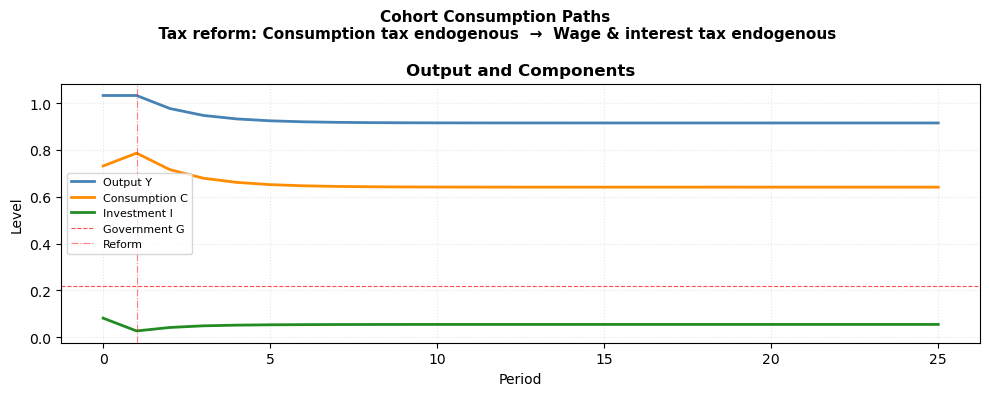

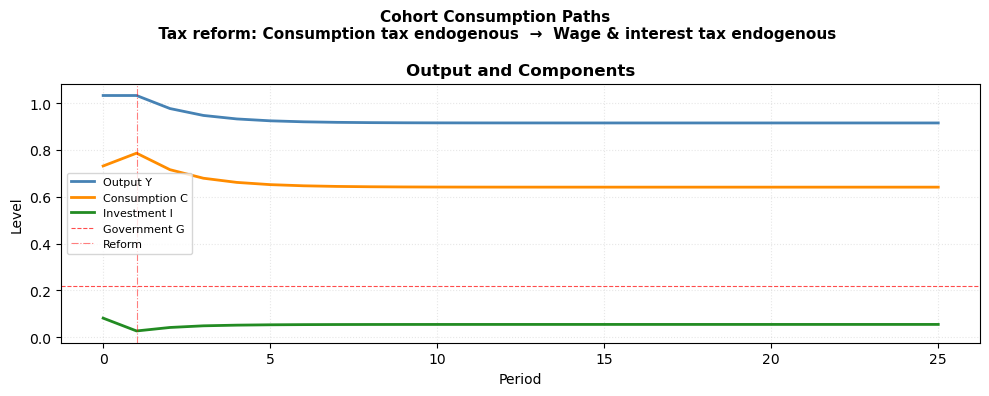

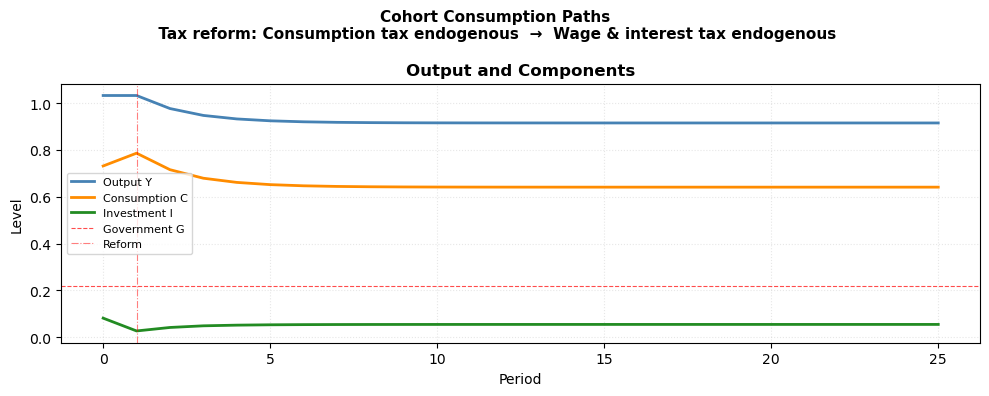

In [14]:
OLG_fortran.plot_output_components()
OLG_kfp.plot_output_components()
OLG_yfp.plot_output_components()